# Marketing Campaign A/B Testing

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/marketing_AB.csv')

In [ ]:
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
user id,0
test group,0
converted,0
total ads,0
most ads day,0
most ads hour,0


In [ ]:
df['test group'].value_counts()

,count
test group,
ad,564577
psa,23524


Data Cleaning

In [ ]:
df = df.drop_duplicates(subset='user id')

In [ ]:
df['converted'] = df['converted'].astype(int)

Conversion Rate

In [ ]:
conversion_rate = df.groupby('test group')['converted'].mean()
print(conversion_rate)

test group
ad     0.025547
psa    0.017854
Name: converted, dtype: float64


In [ ]:
control_rate = conversion_rate['psa']
treatment_rate = conversion_rate['ad']

Visualization

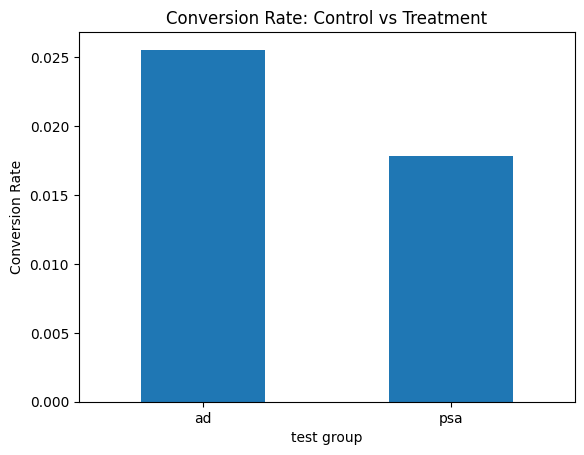

In [ ]:
conversion_rate.plot(kind='bar')
plt.title('Conversion Rate: Control vs Treatment')
plt.ylabel('Conversion Rate')
plt.xticks(rotation=0)
plt.show()

Hypothesis Testing

In [ ]:
control = df[df['test group'] == 'psa']
treatment = df[df['test group'] == 'ad']

In [ ]:
count = [
    treatment['converted'].sum(),
    control['converted'].sum()
]

nobs = [
    treatment.shape[0],
    control.shape[0]
]

z_stat, p_value = proportions_ztest(count, nobs)

print("Z-stat:", z_stat)
print("P-value:", p_value)

Z-stat: 7.3700781265454145
P-value: 1.7052807161559727e-13


In [ ]:
if p_value < 0.05:
    print('Statistically significant difference. Roll out ads')
else:
  print('No significant difference. Do not roll out ads')

Statistically significant difference. Roll out ads


In [ ]:
## Lift
lift = (treatment_rate -  control_rate)/ control_rate
print('Lift:',lift)

Lift: 0.43085064022225833


Segment Analysis

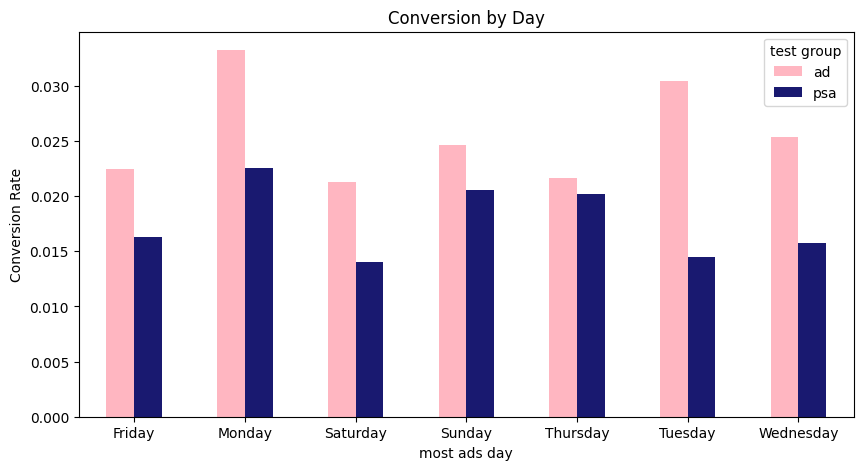

In [ ]:
## Conversion by day
day_analysis = df.groupby(['most ads day','test group'])['converted'].mean().unstack()

my_colors = ['lightpink','midnightblue']
day_analysis.plot(kind='bar', figsize=(10,5),color=my_colors)
plt.title('Conversion by Day')
plt.ylabel('Conversion Rate')
plt.xticks(rotation=0)
plt.show()

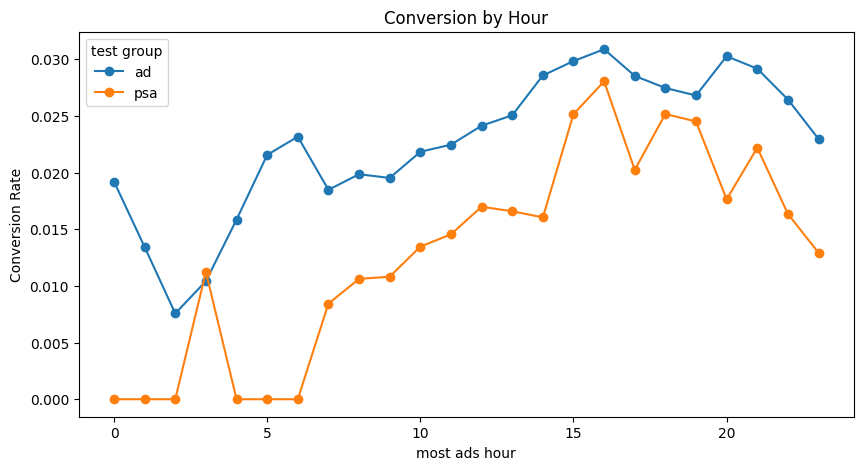

In [ ]:
## Conversion by hour
hour_analysis = df.groupby(['most ads hour','test group'])['converted'].mean().unstack()

hour_analysis.plot(figsize=(10,5),marker='o')
plt.title('Conversion by Hour')
plt.ylabel('Conversion Rate')
plt.show()

/tmp/ipykernel_241/162678867.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('ad_buckets')['converted'].mean().plot(kind='bar', figsize=(10,5),color='sandybrown')


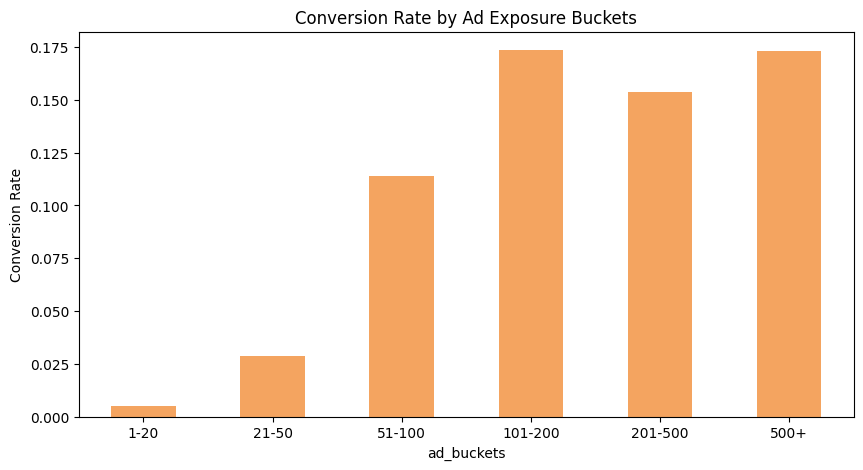

In [ ]:
## Conversion vs Number of Ads
# Create buckets (bins) for the number of ads
df['ad_buckets'] = pd.cut(df['total ads'],
                         bins=[0, 20, 50, 100, 200, 500, 2000],
                         labels=['1-20', '21-50', '51-100', '101-200', '201-500', '500+'])

# Plot the binned data
df.groupby('ad_buckets')['converted'].mean().plot(kind='bar', figsize=(10,5),color='sandybrown')
plt.title("Conversion Rate by Ad Exposure Buckets")
plt.ylabel("Conversion Rate")
plt.xticks(rotation=0)
plt.show()

In [ ]:
print(f"Control Conversion Rate: {control_rate:.4f}")
print(f"Treatment Conversion Rate: {treatment_rate:.4f}")
print(f"Lift: {lift:.2%}")
print(f"P-value: {p_value:.4e}")

Control Conversion Rate: 0.0179
Treatment Conversion Rate: 0.0255
Lift: 43.09%
P-value: 1.7053e-13
